# Chapter 5 | Decision Trees
## Table of Contents
1. [Introduction to Decision Trees](#1.-introduction-to-decision-trees)
2. [Training and Visualizing a Decision Tree](#2.-training-and-visualizing-a-decision-tree)
3. [Estimating Class Probabilities](#3.-estimating-class-probabilities)
4. [Training Algorithm: CART](#4.-training-algorithm-cart)
5. [Computational Complexity](#5.-computational-complexity)
6. [Regularization Hyperparameters](#6.-regularization-hyperparameters)
7. [Regression Trees](#7.-regression-trees)
8. [Limitations of Decision Trees](#8.-limitations-of-decision-trees)

# 1. Introduction to Decision Trees
Decision Trees are versatile ML algorithms capable of performing both classification and regression tasks (and even multioutput tasks). They can fit complex datasets easily and are very intuitive and easy to interpret.

They are also the main building block of random forests (Chapter 7), one of the most powerful ML algorithms available.

## 2. Training and Visualizing a Decision Tree
We can use Scikit-Learn's `DecisionTreeClassifier` class to train a decision tree for classification tasks. Here's an example using the Iris dataset:

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X = iris.data[['petal length (cm)', 'petal width (cm)']].values
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


As we said, Decision Trees are interpretable; we can visualize our classifier by first using the `export_graphviz()` function to export the tree in DOT format:

In [2]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=['petal length (cm)', 'petal width (cm)'],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

We can then use the `graphviz.Source.from_file()` function to render the DOT file and display the decision tree (may need to install `graphviz` in your OS):

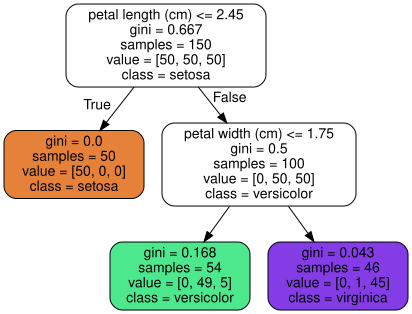

In [8]:
from graphviz import Source

Source.from_file("iris_tree.dot")

It's easy to understand how it makes predictions by following the branches based on feature values until reaching a leaf node that provides the predicted class. We can see how each node contains different information:
- `samples`: number of training instances reaching that node;
- `value`: number of instances of each class reaching that node;
- `class`: predicted class for that node (majority class of instances reaching that node);
- `gini`: Gini impurity measure for that node (how mixed the classes are). A Gini of 0 means all instances belong to a single class. This is computed as:
$$ G_i = 1 - \sum_{k=1}^{n} {p_{i,k}}^2 $$
where:
- $G_i$ is the Gini impurity of node i;
- $p_{i,k}$ is the proportion of instances of class $k$ at node $i$.

Another possibility is to put `criterion="entropy"` when creating the `DecisionTreeClassifier` instance, which will use, instead of Gini impurity, the entropy measure computed as:

$$ H_i = - \sum_{k=1}^{n} p_{i,k} \log_2(p_{i,k}) $$

Most of the time, these 2 criteria lead to similar results.

(Note how Scikit-Learn uses the CART algorithm, which produces binary trees, meaning each internal node has exactly two children; however, other algorithms can produce trees with more than two children per node.)

We can also visualize the decision boundaries created by the decision tree:

<Axes: title={'center': 'Decision Boundary'}, xlabel='Petal Length (cm)', ylabel='Petal Width (cm)'>

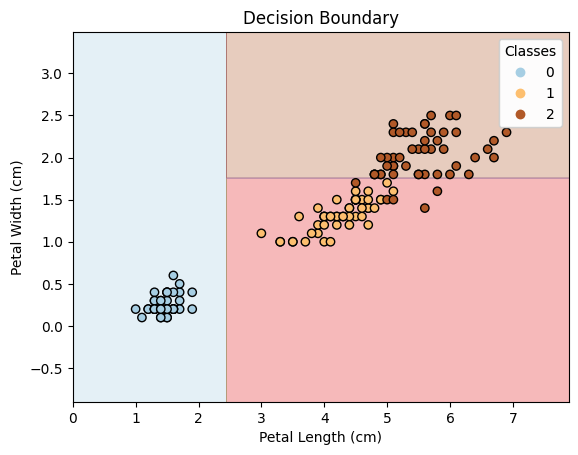

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(clf, X, y, ax=None, cmap='Paired'):
    if ax is None:
        ax = plt.gca()
        
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=cmap)
    legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
    ax.add_artist(legend1)
    ax.set_xlabel('Petal Length (cm)')
    ax.set_ylabel('Petal Width (cm)')
    ax.set_title('Decision Boundary')
    return ax

plot_decision_boundary(tree_clf, X, y)

Note how the vertical Line at `petal length (cm) = 2.45` represents the first tplot (depth 0); since the lefthand area is pure, it cannot be split further.

However, the righthand area is impure, so it is split again at depth 1 based on `petal width (cm) = 1.75`.

Since `max_depth=2`, the tree cannot be split further, even though the two resulting areas are still impure.

## 3. Estimating Class Probabilities
A decision tree can also estimate class probabilities for a specific instance: it first find the leaf node where the instance ends up, then it returns the ratio of each class in that node. 

For example, let's estimate the class probabilities for an Iris flower with a petal length of 5 cm and a petal width of 1.5 cm: this would end up in the depth-2 left node, with probabilties:
- $0/54 = 0%$ for Iris-Setosa;
- $49/54 = 90.7%$ for Iris-Versicolor;
- $5/54 = 9.3%$ for Iris-Virginica.

In [10]:
tree_clf.predict_proba([[5, 1.5]]).round(3)

array([[0.   , 0.907, 0.093]])

Given that, the predicted class would be 1 (Iris-Versicolor):

In [12]:
tree_clf.predict([[5, 1.5]])

array([1])

## 4. Training Algorithm: CART
The CART (Classification and Regression Trees) algorithm is used by Scikit-Learn to train decision trees. It works by splitting the training set into two subsets using a feature $k$ and a threshold $t_k$ (e.g., `petal length <= 2.45 cm`). The algorithm searches for the feature and threshold that result in the purest subsets.

The cost function that CART tries to minimize is:

$$ J(k, t_k) = \frac{m_{left}}{m} G_{left} + \frac{m_{right}}{m} G_{right} $$
where:
- $G_{left}$ and $G_{right}$ are the Gini impurities of the left and right subsets, respectively;
- $m_{left}$ and $m_{right}$ are the number of instances in the left and right subsets, respectively.

The algorithm continues splitting the subsets recursively until a stopping criterion is met (e.g., nodes are pure, maximum depth is reached and others).

## 5. Computational Complexity
With $m$ training instances and $n$ features:

- Training Complexity: $O(n \times m log_2(m))$ (this is due to comparing all features on all samples at each node);
- Prediction Complexity: $O(log_2(m))$ (this is due to traversing the tree from root to leaf, which takes time proportional to the tree's depth and it's independent of the number of features).

## 6. Regularization Hyperparameters
Being Decision Trees a nonparametric model (i.e., they have parameters, but the number of parameters is not determined prior to training), they make very few assumptions about the data. This makes them very likely to adapt to the training data, fitting it very closely, leading to overfitting.

By contrast, a parametric model makes strong assumptions about the data (e.g., linear model assumes linear relationship between features and target), limiting its flexibility, which may lead to underfitting.

To avoid overfitting, we can use regularization techniques that constrain the model's complexity.

Depending on the type of decision tree algorithm, we have different regularization hyperparameters. In Scikit-Learn's `DecisionTreeClassifier`, we can control:
- `max_depth`: the maximum depth of the tree (default is `None` which means unlimited depth);
- `max_features`: the maximum number of features to consider at each split (default is `None` which means all features);
- `max_leaf_nodes`: the maximum number of leaf nodes (default is `None` which means unlimited);
- `min_samples_split`: the minimum number of samples a node must have to be split (default is `2`);
- `min_samples_leaf`: the minimum number of samples a leaf node must have (default is `1`);
- `min_weight_fraction_leaf`: the minimum weighted fraction of the sum total of weights a leaf node must have (default is `0.0`).

Increasing `min_*` hyperparameters or decreasing `max_*` hyperparameters will regularize the model.

(Other algorithms train the decision tree without restrictions and then prune unnecessary nodes (i.e., nodes whose purity improvement is not statistically significant; this is done with statistical tests, such as the chi-squared test).)

Let's try some regularization techniques on the moon dataset:

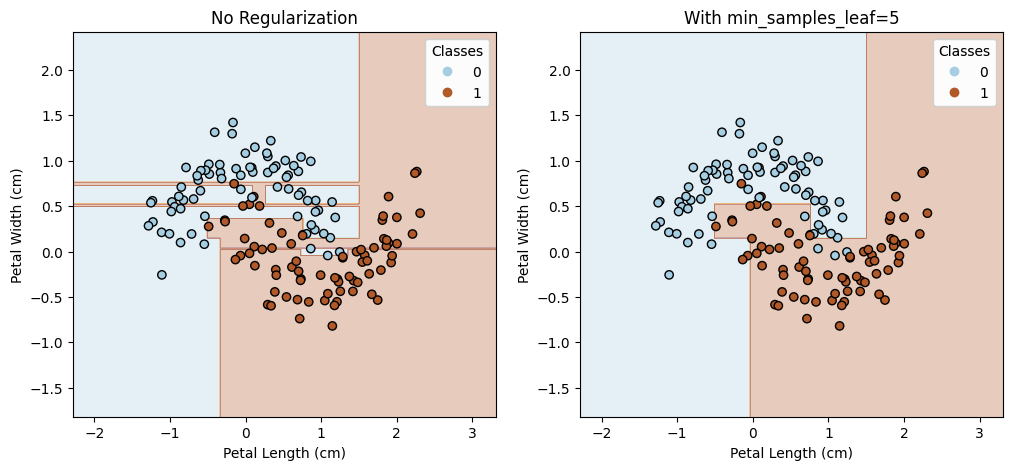

In [14]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples = 150, noise = 0.2, random_state=42)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

tree_clf1.fit(X, y)
tree_clf2.fit(X, y)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(tree_clf1, X, y)
plt.title("No Regularization")
plt.subplot(1, 2, 2)
plot_decision_boundary(tree_clf2, X, y)
plt.title("With min_samples_leaf=5")
plt.show()

It seems that the righthand plot will generalize better than the lefthand one. Let's verify this generating a test set with different random seed:

In [16]:
X_test, y_test = make_moons(n_samples=1000, noise=0.2, random_state=43)

tree_clf1.score(X_test, y_test), tree_clf2.score(X_test, y_test)

(0.898, 0.92)

## 7. Regression Trees
We can use Scikit-Learn's `DecisionTreeRegressor` class to train a decision tree for regression tasks. Here's an example using a noisy quadratic synthetic dataset:

In [17]:
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X = np.random.rand(200, 1) - 0.5
y = X ** 2 + 0.025 * np.random.randn(200, 1)

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [18]:
export_graphviz(
    tree_reg,
    out_file="reg_tree.dot",
    feature_names=['x'],
    rounded=True,
    filled=True
)

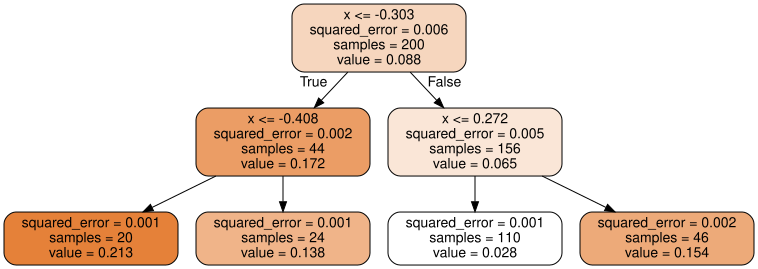

In [19]:
Source.from_file("reg_tree.dot")

This is very similar to the classification case, but instead of predicting classes, the leaf nodes predict continuous values. It also reports the mean squared error over the training instances reaching that node.

Let's visualize the predictions:

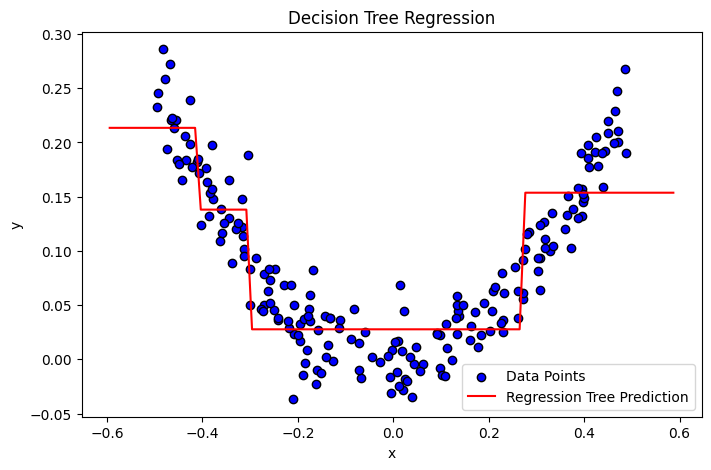

In [ ]:
def plot_regression_tree(clf, X, y, ax=None):
    if ax is None:
        ax = plt.gca()
        
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    xx = np.linspace(x_min, x_max, 100).reshape(-1, 1)
    y_pred = clf.predict(xx)
    
    ax.scatter(X, y, color='blue', edgecolor='k', label='Data Points')
    ax.plot(xx, y_pred, color='red', label='Regression Tree Prediction')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('Decision Tree Regression')
    ax.legend()
    return ax

plt.figure(figsize=(8, 5))
plot_regression_tree(tree_reg, X, y)
plt.show()

As before, the training algorithm is CART, but the cost function to minimize is now the MSE (Mean Squared Error):

$$ J(k, t_k) = \frac{m_{left}}{m} MSE_{left} + \frac{m_{right}}{m} MSE_{right} $$
where:
- $MSE_{left}$ and $MSE_{right}$ are the Mean Squared Errors of the left and right subsets, respectively and are computed as:
$$ MSE = \frac{\sum_{i \in node} (\hat y_{node}-y^{(i)})^2}{m_{node}} $$
where:
$$ \hat y_{node} = \frac{\sum_{i \in node} y^{(i)}}{m_{node}} $$

## 8. Limitations of Decision Trees
Despite their advantages, Decision Trees have some limitations.

The first big limitation is their **Sensitivity to Axis Orientation**: since decision trees make splits based on feature values, the decision boundaries are always orthogonal to the feature axes. This means that if the data is rotated, the decision tree may need to create more splits to capture the same patterns, leading to a more complex tree that may overfit the training data (below an example of the same linearly separable dataset, once with axis-aligned features and once with rotated features):

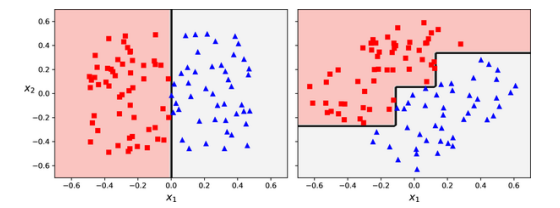

A solution for this is applying scaling and then PCA (Chapter 8). This usually makes things easier for the decision tree to learn simpler decision boundaries. Let's see an example on the iris dataset:

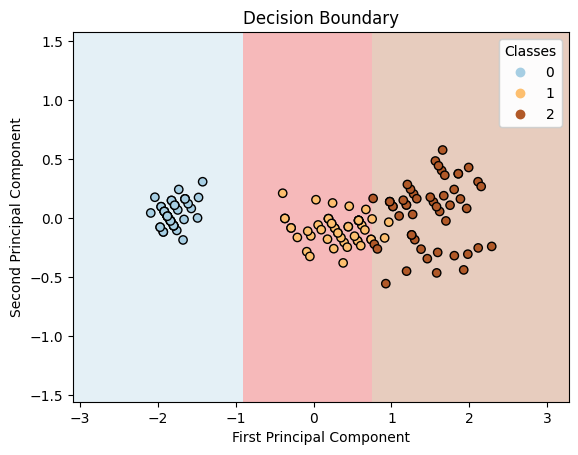

In [23]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X = iris.data[['petal length (cm)', 'petal width (cm)']].values
y = iris.target

pipeline = make_pipeline(
    StandardScaler(),
    PCA())

X_transformed = pipeline.fit_transform(X)
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_transformed, y)

plot_decision_boundary(tree_clf, X_transformed, y)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.show()

As we can see, we obtained a classifier that fits the data almost perfectly using only one feature (the first principal component).

Another limitation of Decision Trees is their **High Variance**: small changes in the data and/or hyperparameters can lead to very different trees (this is due to the sthochastic nature of the splitting process).

A solution to this problem is to average the predictions of many trees; such methods are called ensemble methods; most particularly, most famous ensemble method based on decision trees is the Random Forest algorithm (Chapter 7).